In [1]:
import numpy as np
import matplotlib.pyplot as plt

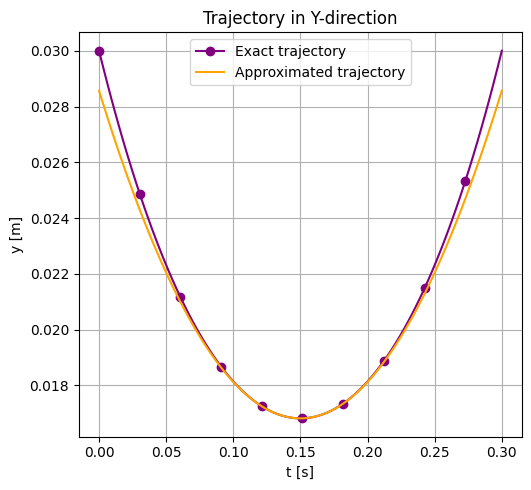

In [13]:
# --- パラメータの設定 ---
g = 9.81
z = 158 * 0.001
Tc = np.sqrt(z/g) # 時定数

# 初期状態 [位置, 速度]
x0, vx0 = -0.04, 0.5
y0 = 0.03

# one step time
T_sup = 0.3

vy0 = (y0/Tc) * ( np.sinh(T_sup/Tc) / ( -1 - np.cosh(T_sup/Tc) ) )

# 時間軸の設定 (0秒から1.0秒まで)
t = np.linspace(0, T_sup, 100)

# --- 関数の計算 ---
# x(t) = x(0)*cosh(t/Tc) + Tc*x_dot(0)*sinh(t/Tc)
x_t = x0 * np.cosh(t/Tc) + Tc * vx0 * np.sinh(t/Tc)
y_t = y0 * np.cosh(t/Tc) + Tc * vy0 * np.sinh(t/Tc)

vx_t = x0 / Tc * np.sinh(t/Tc) + vx0 * np.cosh(t/Tc)
vy_t = y0 / Tc * np.sinh(t/Tc) + vy0 * np.cosh(t/Tc)

C0 = np.cosh(T_sup/(2*Tc))
S0 = np.sinh(T_sup/(2*Tc))

A = (y0 * C0 + Tc * vy0 * S0)
B = (y0/Tc * S0 + vy0 * C0)
C = A / (2 * Tc*Tc)

a = C
b = B - 2 * C * T_sup/2
c = A - B * T_sup/2 + C * (T_sup/2)**2
approx_y_t = a * t**2 + b * t + c
# approx_y_t = y0 * 1/2 * 1/Tc*Tc * t*t + vy0 * t + y0

# --- プロット ---
plt.figure(figsize=(10, 5))

# 2. Yの軌跡
plt.subplot(1, 2, 2)
plt.plot(t, y_t, marker='o', markevery=10, color='purple', label='Exact trajectory')
plt.plot(t, approx_y_t, color='orange', label='Approximated trajectory')
plt.title('Trajectory in Y-direction')
plt.xlabel('t [s]')
plt.ylabel('y [m]')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()